In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import jax
import jax.random as jr
import jax.numpy as jnp
import matplotlib.pyplot as plt

from bridgeop.utils.trainer import TrainerModule, ScoreModel
from bridgeop.utils.data import DataFactory
from bridgeop.utils.configs import load_config
from bridgeop.diffusion.bridge import DiffusionBridge
from bridgeop.neuralop.uno import CTUNO1D

In [9]:
ckpt_path = f"../ckpts/butterfly_eulerian/"
config = load_config("butterfly_eulerian")
    
cwd = os.getcwd()
ckpt_path = os.path.join(cwd, ckpt_path)
ckpt_path = os.path.normpath(ckpt_path)
config.training.dir = ckpt_path

x0 = DataFactory.create(config.data.data_type, config.data.x0)
xT = DataFactory.create(config.data.data_type, config.data.xT)
x0_eval = x0.eval(150)
xT_eval = xT.eval(150)

In [4]:
print(f"x0 shape: {x0_eval.shape}")
print(f"xT shape: {xT_eval.shape}")

x0 shape: (150, 2)
xT shape: (150, 2)


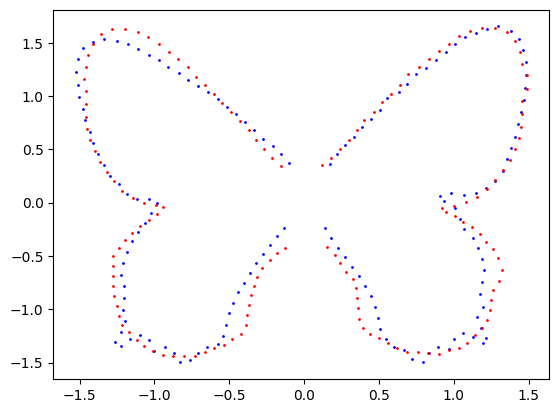

In [5]:
plt.scatter(x0_eval[:, 0], x0_eval[:, 1], s=1, c="blue", label="x0")
plt.scatter(xT_eval[:, 0], xT_eval[:, 1], s=1, c="red", label="xT")

In [6]:
db = DiffusionBridge(
    sde_type=config.db.sde_type,
    sde_config=config.db.sde_config,
)
model = CTUNO1D(**config.model)
trainer = TrainerModule(db, model, config.training)
trainer.train_model(x0=None, mode="pretrained")

Number of trainable parameters: 193,762


/home/ubuntu/miniconda3/envs/sop/lib/python3.10/site-packages/orbax/checkpoint/_src/serialization/type_handlers.py:1251: UserWarning: Couldn't find sharding info under RestoreArgs. Populating sharding info from sharding file. Please note restoration time will be slightly increased due to reading from file instead of directly from RestoreArgs. Note also that this option is unsafe when restoring on a different topology than the checkpoint was saved with.
  warnings.warn(


Model loaded from /home/ubuntu/projects/scoreoperator/ckpts/butterfly_eulerian/checkpoint__step_10000


In [7]:
print(config)

data:
  data_type: butterfly
  x0:
    name: allancastria_cerisyi
  xT:
    name: archon_apollinus
db:
  sde_config:
    T: 1.0
    bm_shape: !!python/tuple
    - 100
    - 100
    - 2
    dt: 0.01
    k_alpha: 0.1
    k_sigma: 10
    x_shape: !!python/tuple
    - 32
    - 2
  sde_type: eulerian
model:
  c: 32
  d_ls: !!python/tuple
  - 32
  - 32
  - 32
  - 32
  d_u: 2
  d_v: 2
  modes_ls: !!python/tuple
  - 12
  - 8
  - 6
training:
  batch_size: 16
  ckpt_freq: 1000
  dir: /home/ubuntu/projects/scoreoperator/ckpts/butterfly_eulerian
  lr: 0.001
  n_iters: 10000
  seed: 42



In [19]:
score_model = ScoreModel(trainer)
# score_model = lambda t, x: (x0_eval - x) / (t + 1e-8)


config.db.sde_config.x_shape = (100, 2)
config.db.sde_config.k_alpha = 0.1
config.db.sde_config.k_sigma = 0.01
# config.db.sde_config.bm_shape = (100, 100, 2)
eval_db = DiffusionBridge(
    sde_type=config.db.sde_type,
    sde_config=config.db.sde_config,
)

xs, *_ = eval_db.solve_forward_sde(
    x0=jnp.zeros_like(x0_eval),
    rng_key=jax.random.PRNGKey(config.training.seed),
)

# ys = eval_db.solve_reverse_bridge(
#     rng_key=jax.random.PRNGKey(config.training.seed),
#     xT=xT_eval - x0_eval,
#     model=score_model,
# )

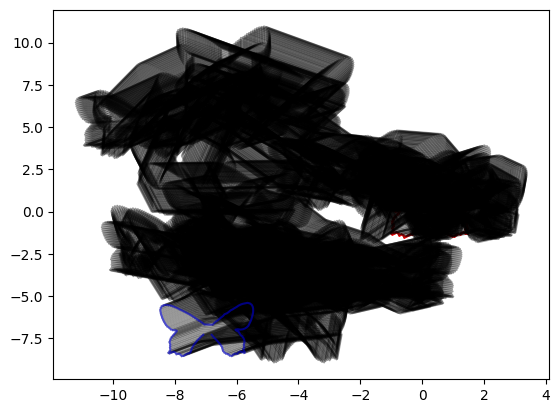

In [20]:
plt.scatter(xs[0][:, 0] + x0_eval[:, 0], xs[0][:, 1] + x0_eval[:, 1], s=1, c="red")
for i in range(xs.shape[1]):
    plt.plot(xs[:, i, 0] + x0_eval[None, i, 0], xs[:, i, 1] + x0_eval[None, i, 1], c="black", alpha=0.4)
plt.plot(xs[-1][:, 0] + x0_eval[:, 0], xs[-1][:, 1] + x0_eval[:, 1], c="blue", alpha=0.5)

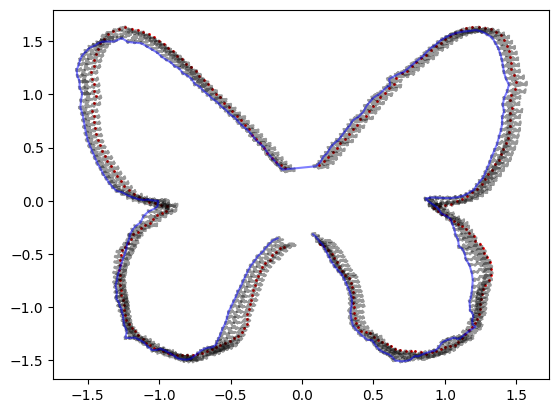

In [6]:
plt.scatter(ys[0][:, 0] + x0_eval[:, 0], ys[0][:, 1] + x0_eval[:, 1], s=1, c="red")
for i in range(ys.shape[1]):
    plt.plot(ys[:, i, 0] + x0_eval[None, i, 0], ys[:, i, 1] + x0_eval[None, i, 1], c="black", alpha=0.4)
plt.plot(ys[-1][:, 0] + x0_eval[:, 0], ys[-1][:, 1] + x0_eval[:, 1], c="blue", alpha=0.5)